In [2]:
import sys
import os
import numpy as np
import scipy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sys.path.append(os.path.abspath('../library'))
import data as d
import preprocess as p
import utils as u
import bayes as b
import pipeline
import results as r
import figures as figs

### Qiu 200ms

In [ ]:
mouse_ID = 'C57_913_Qiu'
Qiu_200 = d.MouseData(mouse_ID, *p.preprocess_data(d.load_data(mouse_ID, tau=0.2)))
Qiu_200.tau = 0.2 # size of time bin of the data in seconds
Qiu_200.rewardzone = [46,47,48,49]

In [ ]:
posterior_200, decoded_pos_200 = pipeline.run_decoder(Qiu_200)

In [ ]:
confusion_mtx_200, accuracy_200, errors_200, mse_200, rt_mse_200 = pipeline.run_results(
    Qiu_200,
    posterior_200,
    decoded_pos_200
)

### Qiu 100ms in Chunks

In [ ]:
mouse_ID = 'C57_913_Qiu'
Qiu_100 = d.MouseData(mouse_ID, *p.preprocess_data(d.load_data(mouse_ID, tau=0.1)))
Qiu_100.tau = 0.1 # size of time bin of the data in seconds
Qiu_100.rewardzone = [46,47,48,49]

In [ ]:
Qiu_100.posterior_chunks, Qiu_100.decoded_pos_chunks = pipeline.run_decoder_chunks(Qiu_100, smoothfactor=0.2)
Qiu_100.results_allchunks = pipeline.run_results_chunks(Qiu_100, Qiu_100.posterior_chunks, Qiu_100.decoded_pos_chunks, 46, 10)

In [ ]:
print(Qiu_100.results_allchunks['mean_accuracy'])
print(Qiu_100.results_allchunks['mean_error'])

figs.plot_confusion_mtx(Qiu_100, Qiu_100.results_allchunks['confusion_mtx']['lgtlgt'], 'lgtlgt')
figs.plot_confusion_mtx(Qiu_100, Qiu_100.results_allchunks['confusion_mtx']['drkdrk'], 'drkdrk')
figs.plot_confusion_mtx(Qiu_100, Qiu_100.results_allchunks['confusion_mtx']['lgtdrk'], 'lgtdrk')
figs.plot_confusion_mtx(Qiu_100, Qiu_100.results_allchunks['confusion_mtx']['drklgt'], 'drklgt')

### Qiu 200ms in Chunks no smooth

In [ ]:
mouse_ID = 'C57_913_Qiu'
Qiu_200_nosmooth = d.MouseData(mouse_ID, *p.preprocess_data(d.load_data(mouse_ID, tau=0.2)))
Qiu_200_nosmooth.tau = 0.2 # size of time bin of the data in seconds
Qiu_200_nosmooth.rewardzone = [46,47,48,49]

In [ ]:
Qiu_200_nosmooth.posterior_chunks, Qiu_200_nosmooth.decoded_pos_chunks = pipeline.run_decoder_chunks(Qiu_200_nosmooth, smooth=False)
Qiu_200_nosmooth.results_allchunks = pipeline.run_results_chunks(Qiu_200_nosmooth, Qiu_200_nosmooth.posterior_chunks, Qiu_200_nosmooth.decoded_pos_chunks, 46, 10)

In [ ]:
print(Qiu_200_nosmooth.results_allchunks['mean_accuracy'])
print(Qiu_200_nosmooth.results_allchunks['mean_error'])

figs.plot_confusion_mtx(Qiu_200_nosmooth, Qiu_200_nosmooth.results_allchunks['confusion_mtx']['lgtlgt'], 'lgtlgt')
figs.plot_confusion_mtx(Qiu_200_nosmooth, Qiu_200_nosmooth.results_allchunks['confusion_mtx']['drkdrk'], 'drkdrk')
figs.plot_confusion_mtx(Qiu_200_nosmooth, Qiu_200_nosmooth.results_allchunks['confusion_mtx']['lgtdrk'], 'lgtdrk')
figs.plot_confusion_mtx(Qiu_200_nosmooth, Qiu_200_nosmooth.results_allchunks['confusion_mtx']['drklgt'], 'drklgt')

### Qiu 200ms in Chunks

In [7]:
mouse_ID = 'C57_913_Qiu'
Qiu_200 = d.MouseData(mouse_ID, *p.preprocess_data(d.load_data(mouse_ID, tau=0.2)))
Qiu_200.tau = 0.2 # size of time bin of the data in seconds
Qiu_200.rewardzone = [46,47,48,49]

scipy.io.loadmat failed: Please use HDF reader for matlab v7.3 files, e.g. h5py)
Trying mat73.loadmat...
../datafiles/C57_913_Qiu/time_binned_SpikeInf_200msbins.mat loaded with mat73.loadmat
scipy.io.loadmat failed: Please use HDF reader for matlab v7.3 files, e.g. h5py)
Trying mat73.loadmat...
../datafiles/C57_913_Qiu/time_binned_DiscreteSpikes_200msbins.mat loaded with mat73.loadmat
scipy.io.loadmat failed: Please use HDF reader for matlab v7.3 files, e.g. h5py)
Trying mat73.loadmat...
../datafiles/C57_913_Qiu/target_positions_200msbins.mat loaded with mat73.loadmat
../datafiles/C57_913_Qiu/darktrial_raw.mat loaded with scipy.io.loadmat
scipy.io.loadmat failed: Please use HDF reader for matlab v7.3 files, e.g. h5py)
Trying mat73.loadmat...
../datafiles/C57_913_Qiu/del_trials.mat loaded with mat73.loadmat

Data of: C57_913_Qiu

Spike Probability:
(244, 112, 125)
Trial x Time Bin x Neuron

Discrete Spikes:
(244, 112, 125)
Trial x Time Bin x Neuron

Position Matrices:
(244, 112)
Trial x

In [8]:
Qiu_200.posterior_chunks, Qiu_200.decoded_pos_chunks = pipeline.run_decoder_chunks(Qiu_200, smoothfactor=0.2)
Qiu_200.results_allchunks = pipeline.run_results_chunks(Qiu_200, Qiu_200.posterior_chunks, Qiu_200.decoded_pos_chunks, 46, 10)

1. Masking spikes and position matrix.
smallest first position: 0.0
largest first position: 34.0
2. Getting trial length.
3. Smoothing spikes.
sigma: 1.0, smoothfactor: 0.2
4. Position Binning data and generating firing rates.


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


5. Splitting light vs dark.
6. Scaling firing rates.
higher in dark: 49 | 39.2 %
higher in light: 76 | 60.8 %
higher in dark: 50 | 40.0 %
higher in light: 75 | 60.0 %
Sorting trials and chunking trials.
(15, 112, 125)
(15, 112, 125)
(15, 112, 125)
(15, 112, 125)
(15, 112, 125)
(15, 112, 125)
(15, 112, 125)
(15, 112, 125)
(15, 112, 125)
(15, 112, 125)
(10, 112, 125)
(10, 112, 125)
(10, 112, 125)
(10, 112, 125)
(9, 112, 125)
(9, 112, 125)
(9, 112, 125)
(9, 112, 125)
(9, 112, 125)
(9, 112, 125)
(15, 50, 125)
(15, 50, 125)
(15, 50, 125)
(15, 50, 125)
(15, 50, 125)
(15, 50, 125)
(15, 50, 125)
(15, 50, 125)
(15, 50, 125)
(15, 50, 125)
(10, 50, 125)
(10, 50, 125)
(10, 50, 125)
(10, 50, 125)
(9, 50, 125)
(9, 50, 125)
(9, 50, 125)
(9, 50, 125)
(9, 50, 125)
(9, 50, 125)
(15, 50, 125)
(15, 50, 125)
(15, 50, 125)
(15, 50, 125)
(15, 50, 125)
(15, 50, 125)
(15, 50, 125)
(15, 50, 125)
(15, 50, 125)
(15, 50, 125)
(10, 50, 125)
(10, 50, 125)
(10, 50, 125)
(10, 50, 125)
(9, 50, 125)
(9, 50, 125)
(9, 50,

/Users/andrewlau/code/bayesian_decoder/library/bayes.py:235: RuntimeWarning: Mean of empty slice
  fx = np.nanmean(firingrate, axis=0)        # mean firing rate across trials
/Users/andrewlau/code/bayesian_decoder/library/bayes.py:237: RuntimeWarning: divide by zero encountered in log
  log_lamb = np.log(lamb)                    # log lambda
/Users/andrewlau/code/bayesian_decoder/library/bayes.py:253: RuntimeWarning: invalid value encountered in scalar multiply
  log_pnx_before_sum[t,x,i] = (n_i * log_lamb[x,i]) - lamb[x,i] - log_nfac[t,i]
/Users/andrewlau/code/bayesian_decoder/library/bayes.py:273: RuntimeWarning: divide by zero encountered in log
  log_pn = np.log(np.sum((pnx * px), axis=1))
/Users/andrewlau/code/bayesian_decoder/library/bayes.py:279: RuntimeWarning: invalid value encountered in subtract
  posterior_chunk[test_trial] = np.exp((log_pnx.T + log_px - log_pn).T)
/Users/andrewlau/code/bayesian_decoder/library/bayes.py:286: RuntimeWarning: All-NaN slice encountered
  if np

Chunk  0  lgtlgt completed.
Chunk  0  drkdrk completed.
Chunk  0  lgtdrk completed.
Chunk  0  drklgt completed.
Decoding chunk  1 ...
Chunk  1  lgtlgt completed.
Chunk  1  drkdrk completed.
Chunk  1  lgtdrk completed.
Chunk  1  drklgt completed.
Decoding chunk  2 ...
Chunk  2  lgtlgt completed.
Chunk  2  drkdrk completed.
Chunk  2  lgtdrk completed.
Chunk  2  drklgt completed.
Decoding chunk  3 ...
Chunk  3  lgtlgt completed.
Chunk  3  drkdrk completed.
Chunk  3  lgtdrk completed.
Chunk  3  drklgt completed.
Decoding chunk  4 ...
Chunk  4  lgtlgt completed.
Chunk  4  drkdrk completed.
Chunk  4  lgtdrk completed.
Chunk  4  drklgt completed.
Decoding chunk  5 ...
Chunk  5  lgtlgt completed.
Chunk  5  drkdrk completed.
Chunk  5  lgtdrk completed.
Chunk  5  drklgt completed.
Decoding chunk  6 ...
Chunk  6  lgtlgt completed.
Chunk  6  drkdrk completed.
Chunk  6  lgtdrk completed.
Chunk  6  drklgt completed.
Decoding chunk  7 ...
Chunk  7  lgtlgt completed.
Chunk  7  drkdrk completed.
Chunk 

{'lgtlgt': 0.16273159011781108, 'drkdrk': 0.09333655741954691, 'lgtdrk': 0.0637907325071895, 'drklgt': 0.0411339563053404}
{'lgtlgt': 6.995555555555556, 'drkdrk': 6.37107156380159, 'lgtdrk': 8.071299312341658, 'drklgt': 9.712667660208643}


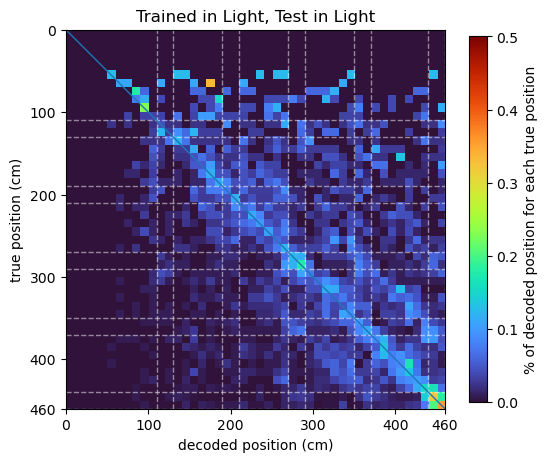

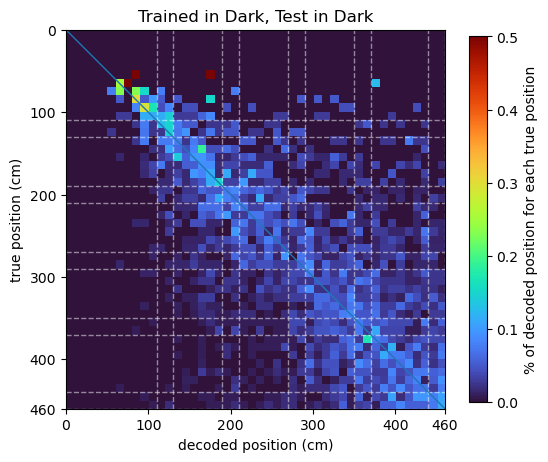

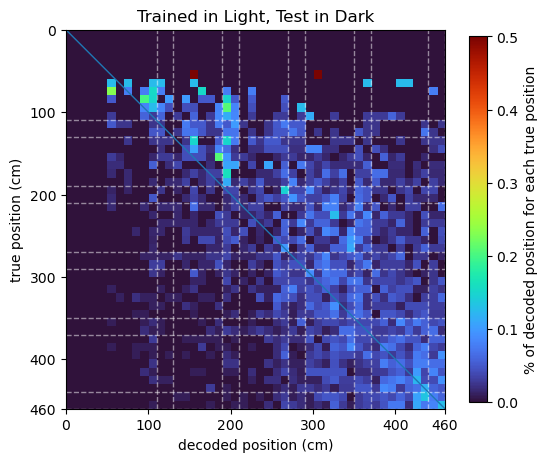

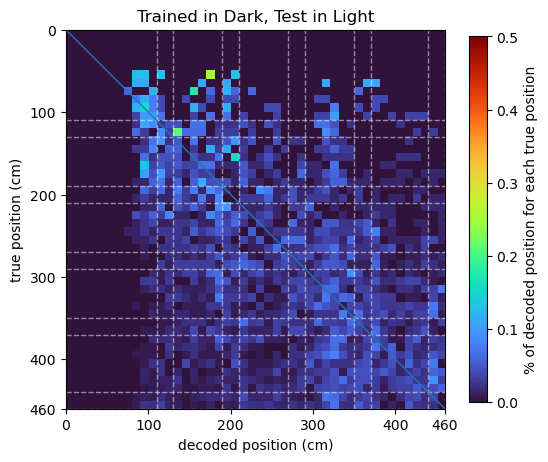

In [9]:
print(Qiu_200.results_allchunks['mean_accuracy'])
print(Qiu_200.results_allchunks['mean_error'])

figs.plot_confusion_mtx(Qiu_200, Qiu_200.results_allchunks['confusion_mtx']['lgtlgt'], 'lgtlgt')
figs.plot_confusion_mtx(Qiu_200, Qiu_200.results_allchunks['confusion_mtx']['drkdrk'], 'drkdrk')
figs.plot_confusion_mtx(Qiu_200, Qiu_200.results_allchunks['confusion_mtx']['lgtdrk'], 'lgtdrk')
figs.plot_confusion_mtx(Qiu_200, Qiu_200.results_allchunks['confusion_mtx']['drklgt'], 'drklgt')

### Napoleon 200ms in Chunks

In [ ]:
mouse_ID = 'C57_59_Napoleon'
Napoleon_200 = d.MouseData(mouse_ID, *p.preprocess_data(d.load_data(mouse_ID, tau=0.2)))
Napoleon_200.tau = 0.2 # size of time bin of the data in seconds
Napoleon_200.rewardzone = [46,47,48,49,50,51,52,53,54,55,56,57,58,59]

In [ ]:
Napoleon_200.posterior_chunks, Napoleon_200.decoded_pos_chunks = pipeline.run_decoder_chunks(Napoleon_200, smoothfactor=0.2)
Napoleon_200.results_allchunks = pipeline.run_results_chunks(Napoleon_200, Napoleon_200.posterior_chunks, Napoleon_200.decoded_pos_chunks, 46, 10)

In [ ]:
print(Napoleon_200.results_allchunks['mean_accuracy'])
print(Napoleon_200.results_allchunks['mean_error'])

figs.plot_confusion_mtx(Napoleon_200, Napoleon_200.results_allchunks['confusion_mtx']['lgtlgt'], 'lgtlgt')
figs.plot_confusion_mtx(Napoleon_200, Napoleon_200.results_allchunks['confusion_mtx']['drkdrk'], 'drkdrk')
figs.plot_confusion_mtx(Napoleon_200, Napoleon_200.results_allchunks['confusion_mtx']['lgtdrk'], 'lgtdrk')
figs.plot_confusion_mtx(Napoleon_200, Napoleon_200.results_allchunks['confusion_mtx']['drklgt'], 'drklgt')

### Octavius 200ms in Chunks

In [4]:
mouse_ID = 'C57_60_Octavius'
Octavius_200 = d.MouseData(mouse_ID, *p.preprocess_data(d.load_data(mouse_ID, tau=0.2)))
Octavius_200.tau = 0.2 # size of time bin of the data in seconds
Octavius_200.rewardzone = [46,47,48,49,50,51,52,53,54,55,56,57,58,59]

scipy.io.loadmat failed: Please use HDF reader for matlab v7.3 files, e.g. h5py)
Trying mat73.loadmat...
../datafiles/C57_60_Octavius/time_binned_SpikeInf_200msbins.mat loaded with mat73.loadmat
scipy.io.loadmat failed: Please use HDF reader for matlab v7.3 files, e.g. h5py)
Trying mat73.loadmat...
../datafiles/C57_60_Octavius/time_binned_DiscreteSpikes_200msbins.mat loaded with mat73.loadmat
scipy.io.loadmat failed: Please use HDF reader for matlab v7.3 files, e.g. h5py)
Trying mat73.loadmat...
../datafiles/C57_60_Octavius/target_positions_200msbins.mat loaded with mat73.loadmat
scipy.io.loadmat failed: Please use HDF reader for matlab v7.3 files, e.g. h5py)
Trying mat73.loadmat...
../datafiles/C57_60_Octavius/darktrial_raw.mat loaded with mat73.loadmat
../datafiles/C57_60_Octavius/del_trials.mat loaded with scipy.io.loadmat

Data of: C57_60_Octavius

Spike Probability:
(170, 121, 85)
Trial x Time Bin x Neuron

Discrete Spikes:
(170, 121, 85)
Trial x Time Bin x Neuron

Position Matric

In [5]:
Octavius_200.posterior_chunks, Octavius_200.decoded_pos_chunks = pipeline.run_decoder_chunks(Octavius_200, smoothfactor=0.2)
Octavius_200.results_allchunks = pipeline.run_results_chunks(Octavius_200, Octavius_200.posterior_chunks, Octavius_200.decoded_pos_chunks, 46, 10)

1. Masking spikes and position matrix.
smallest first position: 0.0
largest first position: 32.0
2. Getting trial length.
3. Smoothing spikes.
sigma: 1.0, smoothfactor: 0.2
4. Position Binning data and generating firing rates.


/Users/andrewlau/code/bayesian_decoder/library/utils.py:400: RuntimeWarning: Mean of empty slice
  activity = np.nanmean(activity, axis=0)


5. Splitting light vs dark.
6. Scaling firing rates.
higher in dark: 37 | 43.529411764705884 %
higher in light: 48 | 56.470588235294116 %
higher in dark: 37 | 43.529411764705884 %
higher in light: 48 | 56.470588235294116 %
Sorting trials and chunking trials.
(12, 121, 85)
(12, 121, 85)
(11, 121, 85)
(11, 121, 85)
(11, 121, 85)
(11, 121, 85)
(11, 121, 85)
(11, 121, 85)
(11, 121, 85)
(11, 121, 85)
(6, 121, 85)
(6, 121, 85)
(6, 121, 85)
(6, 121, 85)
(6, 121, 85)
(6, 121, 85)
(6, 121, 85)
(6, 121, 85)
(5, 121, 85)
(5, 121, 85)
(12, 50, 85)
(12, 50, 85)
(11, 50, 85)
(11, 50, 85)
(11, 50, 85)
(11, 50, 85)
(11, 50, 85)
(11, 50, 85)
(11, 50, 85)
(11, 50, 85)
(6, 50, 85)
(6, 50, 85)
(6, 50, 85)
(6, 50, 85)
(6, 50, 85)
(6, 50, 85)
(6, 50, 85)
(6, 50, 85)
(5, 50, 85)
(5, 50, 85)
(12, 50, 85)
(12, 50, 85)
(11, 50, 85)
(11, 50, 85)
(11, 50, 85)
(11, 50, 85)
(11, 50, 85)
(11, 50, 85)
(11, 50, 85)
(11, 50, 85)
(6, 50, 85)
(6, 50, 85)
(6, 50, 85)
(6, 50, 85)
(6, 50, 85)
(6, 50, 85)
(6, 50, 85)
(6, 50,

/Users/andrewlau/code/bayesian_decoder/library/bayes.py:235: RuntimeWarning: Mean of empty slice
  fx = np.nanmean(firingrate, axis=0)        # mean firing rate across trials
/Users/andrewlau/code/bayesian_decoder/library/bayes.py:237: RuntimeWarning: divide by zero encountered in log
  log_lamb = np.log(lamb)                    # log lambda
/Users/andrewlau/code/bayesian_decoder/library/bayes.py:253: RuntimeWarning: invalid value encountered in scalar multiply
  log_pnx_before_sum[t,x,i] = (n_i * log_lamb[x,i]) - lamb[x,i] - log_nfac[t,i]
/Users/andrewlau/code/bayesian_decoder/library/bayes.py:273: RuntimeWarning: divide by zero encountered in log
  log_pn = np.log(np.sum((pnx * px), axis=1))
/Users/andrewlau/code/bayesian_decoder/library/bayes.py:279: RuntimeWarning: invalid value encountered in subtract
  posterior_chunk[test_trial] = np.exp((log_pnx.T + log_px - log_pn).T)
/Users/andrewlau/code/bayesian_decoder/library/bayes.py:286: RuntimeWarning: All-NaN slice encountered
  if np

Chunk  0  lgtlgt completed.
Chunk  0  drkdrk completed.
Chunk  0  lgtdrk completed.
Chunk  0  drklgt completed.
Decoding chunk  1 ...
Chunk  1  lgtlgt completed.
Chunk  1  drkdrk completed.
Chunk  1  lgtdrk completed.
Chunk  1  drklgt completed.
Decoding chunk  2 ...
Chunk  2  lgtlgt completed.
Chunk  2  drkdrk completed.
Chunk  2  lgtdrk completed.
Chunk  2  drklgt completed.
Decoding chunk  3 ...
Chunk  3  lgtlgt completed.
Chunk  3  drkdrk completed.
Chunk  3  lgtdrk completed.
Chunk  3  drklgt completed.
Decoding chunk  4 ...
Chunk  4  lgtlgt completed.
Chunk  4  drkdrk completed.
Chunk  4  lgtdrk completed.
Chunk  4  drklgt completed.
Decoding chunk  5 ...
Chunk  5  lgtlgt completed.
Chunk  5  drkdrk completed.
Chunk  5  lgtdrk completed.
Chunk  5  drklgt completed.
Decoding chunk  6 ...
Chunk  6  lgtlgt completed.
Chunk  6  drkdrk completed.
Chunk  6  lgtdrk completed.
Chunk  6  drklgt completed.
Decoding chunk  7 ...
Chunk  7  lgtlgt completed.
Chunk  7  drkdrk completed.
Chunk 

{'lgtlgt': 0.2532760618850204, 'drkdrk': 0.09064282240150126, 'lgtdrk': 0.049283415908085305, 'drklgt': 0.052570507405973334}
{'lgtlgt': 6.277082697589258, 'drkdrk': 5.943639291465378, 'lgtdrk': 9.679245283018869, 'drklgt': 9.939404934687953}


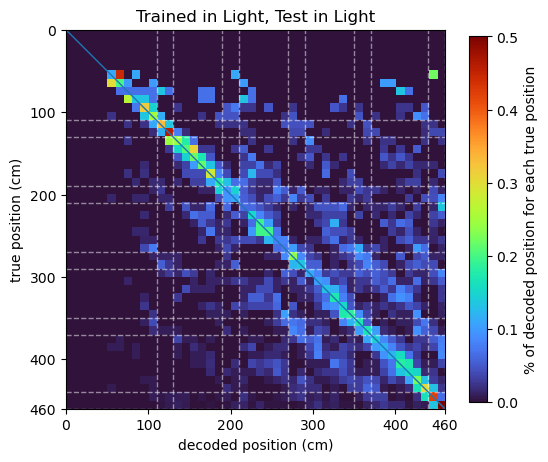

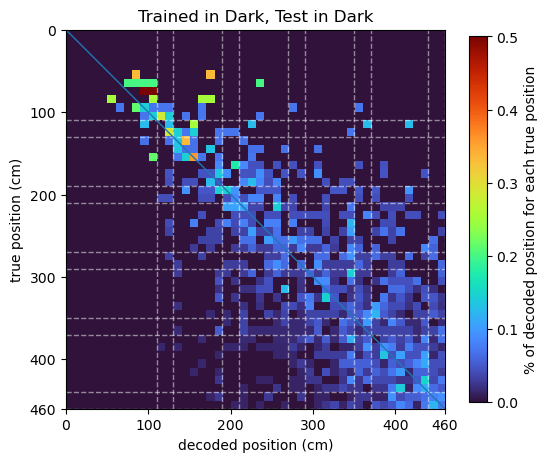

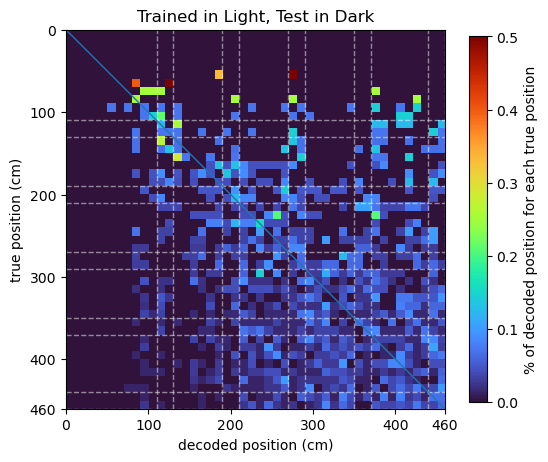

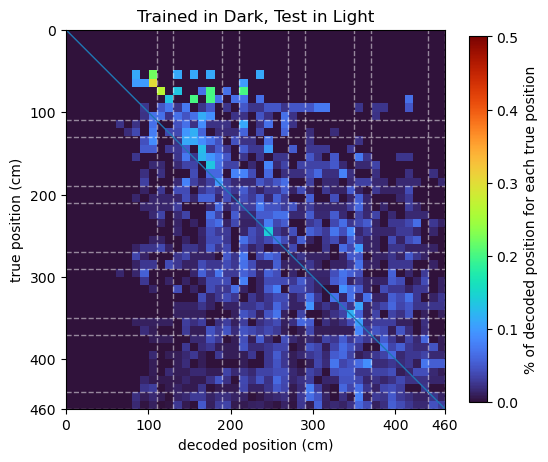

In [6]:
print(Octavius_200.results_allchunks['mean_accuracy'])
print(Octavius_200.results_allchunks['mean_error'])

figs.plot_confusion_mtx(Octavius_200, Octavius_200.results_allchunks['confusion_mtx']['lgtlgt'], 'lgtlgt', save=True)
figs.plot_confusion_mtx(Octavius_200, Octavius_200.results_allchunks['confusion_mtx']['drkdrk'], 'drkdrk', save=True)
figs.plot_confusion_mtx(Octavius_200, Octavius_200.results_allchunks['confusion_mtx']['lgtdrk'], 'lgtdrk', save=True)
figs.plot_confusion_mtx(Octavius_200, Octavius_200.results_allchunks['confusion_mtx']['drklgt'], 'drklgt', save=True)

### Priamus 200ms in Chunks

In [ ]:
mouse_ID = 'C57_61_Priamus'
Priamus_200 = d.MouseData(mouse_ID, *p.preprocess_data(d.load_data(mouse_ID, tau=0.2)))
Priamus_200.tau = 0.2 # size of time bin of the data in seconds
Priamus_200.rewardzone = [46,47,48,49,50,51,52,53,54,55,56,57,58,59]

In [ ]:
Priamus_200.posterior_chunks, Priamus_200.decoded_pos_chunks = pipeline.run_decoder_chunks(Priamus_200, smoothfactor=0.2)
Priamus_200.results_allchunks = pipeline.run_results_chunks(Priamus_200, Priamus_200.posterior_chunks, Priamus_200.decoded_pos_chunks, 46, 10)

In [ ]:
print(Priamus_200.results_allchunks['mean_accuracy'])
print(Priamus_200.results_allchunks['mean_error'])

figs.plot_confusion_mtx(Priamus_200, Priamus_200.results_allchunks['confusion_mtx']['lgtlgt'], 'lgtlgt')
figs.plot_confusion_mtx(Priamus_200, Priamus_200.results_allchunks['confusion_mtx']['drkdrk'], 'drkdrk')
figs.plot_confusion_mtx(Priamus_200, Priamus_200.results_allchunks['confusion_mtx']['lgtdrk'], 'lgtdrk')
figs.plot_confusion_mtx(Priamus_200, Priamus_200.results_allchunks['confusion_mtx']['drklgt'], 'drklgt')

### Serena 200ms in Chunks

In [ ]:
mouse_ID = 'C57_915_Serena'
Serena_200 = d.MouseData(mouse_ID, *p.preprocess_data(d.load_data(mouse_ID, tau=0.2)))
Serena_200.tau = 0.2 # size of time bin of the data in seconds
Serena_200.rewardzone = [46,47,48,49]

In [ ]:
Serena_200.posterior_chunks, Serena_200.decoded_pos_chunks = pipeline.run_decoder_chunks(Serena_200, smoothfactor=0.2)
Serena_200.results_allchunks = pipeline.run_results_chunks(Serena_200, Serena_200.posterior_chunks, Serena_200.decoded_pos_chunks, 46, 10)

In [ ]:
print(Serena_200.results_allchunks['mean_accuracy'])
print(Serena_200.results_allchunks['mean_error'])

figs.plot_confusion_mtx(Serena_200, Serena_200.results_allchunks['confusion_mtx']['lgtlgt'], 'lgtlgt')
figs.plot_confusion_mtx(Serena_200, Serena_200.results_allchunks['confusion_mtx']['drkdrk'], 'drkdrk')
figs.plot_confusion_mtx(Serena_200, Serena_200.results_allchunks['confusion_mtx']['lgtdrk'], 'lgtdrk')
figs.plot_confusion_mtx(Serena_200, Serena_200.results_allchunks['confusion_mtx']['drklgt'], 'drklgt')

## Obsolete

### Qiu 100ms

In [ ]:
mouse_ID = 'C57_913_Qiu'
Qiu = d.MouseData(mouse_ID, *p.preprocess_data(d.load_data(mouse_ID)))
Qiu.tau = 0.1 # size of time bin of the data in seconds
Qiu.rewardzone = [46,47,48,49]

In [ ]:
posterior_normal, decoded_pos_normal = pipeline.run_decoder(Qiu)

In [ ]:
confusion_mtx_all, accuracy_all, errors_all, mse_all, rt_mse_all = pipeline.run_results(
    Qiu,
    posterior_normal,
    decoded_pos_normal
)

### Qiu 100ms in chunks

In [ ]:
mouse_ID = 'C57_913_Qiu'
Qiu = d.MouseData(mouse_ID, *p.preprocess_data(d.load_data(mouse_ID)))
Qiu.tau = 0.1 # size of time bin of the data in seconds
Qiu.rewardzone = [46,47,48,49]

In [ ]:
posterior_chunks, decoded_pos_chunks = pipeline.run_decoder_chunks(Qiu)

In [ ]:
results_allchunks = pipeline.run_results_chunks(Qiu, posterior_chunks, decoded_pos_chunks, 46, 10)

In [ ]:
print(results_allchunks['mean_accuracy'])
print(results_allchunks['mean_error'])

### Qiu 200ms in Chunks different smoothfactor

In [ ]:
posterior_chunks_200, decoded_pos_chunks_200 = pipeline.run_decoder_chunks(Qiu_200, smoothfactor=0.1)
results_allchunks_200 = pipeline.run_results_chunks(Qiu_200, posterior_chunks_200, decoded_pos_chunks_200, 46, 10)
print(results_allchunks_200['mean_accuracy'])
print(results_allchunks_200['mean_error'])

In [ ]:
posterior_chunks_200, decoded_pos_chunks_200 = pipeline.run_decoder_chunks(Qiu_200, smoothfactor=0.11)
results_allchunks_200 = pipeline.run_results_chunks(Qiu_200, posterior_chunks_200, decoded_pos_chunks_200, 46, 10)
print(results_allchunks_200['mean_accuracy'])
print(results_allchunks_200['mean_error'])

In [ ]:
posterior_chunks_200, decoded_pos_chunks_200 = pipeline.run_decoder_chunks(Qiu_200, smoothfactor=0.12)
results_allchunks_200 = pipeline.run_results_chunks(Qiu_200, posterior_chunks_200, decoded_pos_chunks_200, 46, 10)
print(results_allchunks_200['mean_accuracy'])
print(results_allchunks_200['mean_error'])

In [ ]:
posterior_chunks_200, decoded_pos_chunks_200 = pipeline.run_decoder_chunks(Qiu_200, smoothfactor=0.13)
results_allchunks_200 = pipeline.run_results_chunks(Qiu_200, posterior_chunks_200, decoded_pos_chunks_200, 46, 10)
print(results_allchunks_200['mean_accuracy'])
print(results_allchunks_200['mean_error'])

In [ ]:
posterior_chunks_200, decoded_pos_chunks_200 = pipeline.run_decoder_chunks(Qiu_200, smoothfactor=0.14)
results_allchunks_200 = pipeline.run_results_chunks(Qiu_200, posterior_chunks_200, decoded_pos_chunks_200, 46, 10)
print(results_allchunks_200['mean_accuracy'])
print(results_allchunks_200['mean_error'])

In [ ]:
posterior_chunks_200, decoded_pos_chunks_200 = pipeline.run_decoder_chunks(Qiu_200, smoothfactor=0.15)
results_allchunks_200 = pipeline.run_results_chunks(Qiu_200, posterior_chunks_200, decoded_pos_chunks_200, 46, 10)
print(results_allchunks_200['mean_accuracy'])
print(results_allchunks_200['mean_error'])

In [ ]:
posterior_chunks_200, decoded_pos_chunks_200 = pipeline.run_decoder_chunks(Qiu_200, smoothfactor=0.16)
results_allchunks_200 = pipeline.run_results_chunks(Qiu_200, posterior_chunks_200, decoded_pos_chunks_200, 46, 10)
print(results_allchunks_200['mean_accuracy'])
print(results_allchunks_200['mean_error'])

In [ ]:
posterior_chunks_200, decoded_pos_chunks_200 = pipeline.run_decoder_chunks(Qiu_200, smoothfactor=0.17)
results_allchunks_200 = pipeline.run_results_chunks(Qiu_200, posterior_chunks_200, decoded_pos_chunks_200, 46, 10)
print(results_allchunks_200['mean_accuracy'])
print(results_allchunks_200['mean_error'])

In [ ]:
posterior_chunks_200, decoded_pos_chunks_200 = pipeline.run_decoder_chunks(Qiu_200, smoothfactor=0.18)
results_allchunks_200 = pipeline.run_results_chunks(Qiu_200, posterior_chunks_200, decoded_pos_chunks_200, 46, 10)
print(results_allchunks_200['mean_accuracy'])
print(results_allchunks_200['mean_error'])

In [ ]:
posterior_chunks_200, decoded_pos_chunks_200 = pipeline.run_decoder_chunks(Qiu_200, smoothfactor=0.19)
results_allchunks_200 = pipeline.run_results_chunks(Qiu_200, posterior_chunks_200, decoded_pos_chunks_200, 46, 10)
print(results_allchunks_200['mean_accuracy'])
print(results_allchunks_200['mean_error'])

In [ ]:
posterior_chunks_200, decoded_pos_chunks_200 = pipeline.run_decoder_chunks(Qiu_200, smoothfactor=0.20)
results_allchunks_200 = pipeline.run_results_chunks(Qiu_200, posterior_chunks_200, decoded_pos_chunks_200, 46, 10)
print(results_allchunks_200['mean_accuracy'])
print(results_allchunks_200['mean_error'])

In [ ]:
posterior_chunks_200, decoded_pos_chunks_200 = pipeline.run_decoder_chunks(Qiu_200, smoothfactor=0.21)
results_allchunks_200 = pipeline.run_results_chunks(Qiu_200, posterior_chunks_200, decoded_pos_chunks_200, 46, 10)
print(results_allchunks_200['mean_accuracy'])
print(results_allchunks_200['mean_error'])

In [ ]:
posterior_chunks_200, decoded_pos_chunks_200 = pipeline.run_decoder_chunks(Qiu_200, smoothfactor=0.22)
results_allchunks_200 = pipeline.run_results_chunks(Qiu_200, posterior_chunks_200, decoded_pos_chunks_200, 46, 10)
print(results_allchunks_200['mean_accuracy'])
print(results_allchunks_200['mean_error'])

In [ ]:
posterior_chunks_200, decoded_pos_chunks_200 = pipeline.run_decoder_chunks(Qiu_200, smoothfactor=0.23)
results_allchunks_200 = pipeline.run_results_chunks(Qiu_200, posterior_chunks_200, decoded_pos_chunks_200, 46, 10)
print(results_allchunks_200['mean_accuracy'])
print(results_allchunks_200['mean_error'])

In [ ]:
posterior_chunks_200, decoded_pos_chunks_200 = pipeline.run_decoder_chunks(Qiu_200, smoothfactor=0.24)
results_allchunks_200 = pipeline.run_results_chunks(Qiu_200, posterior_chunks_200, decoded_pos_chunks_200, 46, 10)
print(results_allchunks_200['mean_accuracy'])
print(results_allchunks_200['mean_error'])

In [ ]:
posterior_chunks_200, decoded_pos_chunks_200 = pipeline.run_decoder_chunks(Qiu_200, smoothfactor=0.25)
results_allchunks_200 = pipeline.run_results_chunks(Qiu_200, posterior_chunks_200, decoded_pos_chunks_200, 46, 10)
print(results_allchunks_200['mean_accuracy'])
print(results_allchunks_200['mean_error'])

In [ ]:
posterior_chunks_200, decoded_pos_chunks_200 = pipeline.run_decoder_chunks(Qiu_200, smoothfactor=0.26)
results_allchunks_200 = pipeline.run_results_chunks(Qiu_200, posterior_chunks_200, decoded_pos_chunks_200, 46, 10)
print(results_allchunks_200['mean_accuracy'])
print(results_allchunks_200['mean_error'])

In [ ]:
posterior_chunks_200, decoded_pos_chunks_200 = pipeline.run_decoder_chunks(Qiu_200, smoothfactor=0.27)
results_allchunks_200 = pipeline.run_results_chunks(Qiu_200, posterior_chunks_200, decoded_pos_chunks_200, 46, 10)
print(results_allchunks_200['mean_accuracy'])
print(results_allchunks_200['mean_error'])

In [ ]:
posterior_chunks_200, decoded_pos_chunks_200 = pipeline.run_decoder_chunks(Qiu_200, smoothfactor=0.28)
results_allchunks_200 = pipeline.run_results_chunks(Qiu_200, posterior_chunks_200, decoded_pos_chunks_200, 46, 10)
print(results_allchunks_200['mean_accuracy'])
print(results_allchunks_200['mean_error'])

In [ ]:
posterior_chunks_200, decoded_pos_chunks_200 = pipeline.run_decoder_chunks(Qiu_200, smoothfactor=0.29)
results_allchunks_200 = pipeline.run_results_chunks(Qiu_200, posterior_chunks_200, decoded_pos_chunks_200, 46, 10)
print(results_allchunks_200['mean_accuracy'])
print(results_allchunks_200['mean_error'])

In [ ]:
posterior_chunks_200, decoded_pos_chunks_200 = pipeline.run_decoder_chunks(Qiu_200, smoothfactor=0.3)
results_allchunks_200 = pipeline.run_results_chunks(Qiu_200, posterior_chunks_200, decoded_pos_chunks_200, 46, 10)
print(results_allchunks_200['mean_accuracy'])
print(results_allchunks_200['mean_error'])

In [ ]:
posterior_chunks_200, decoded_pos_chunks_200 = pipeline.run_decoder_chunks(Qiu_200, smoothfactor=0.31)
results_allchunks_200 = pipeline.run_results_chunks(Qiu_200, posterior_chunks_200, decoded_pos_chunks_200, 46, 10)
print(results_allchunks_200['mean_accuracy'])
print(results_allchunks_200['mean_error'])

In [ ]:
posterior_chunks_200, decoded_pos_chunks_200 = pipeline.run_decoder_chunks(Qiu_200, smoothfactor=0.32)
results_allchunks_200 = pipeline.run_results_chunks(Qiu_200, posterior_chunks_200, decoded_pos_chunks_200, 46, 10)
print(results_allchunks_200['mean_accuracy'])
print(results_allchunks_200['mean_error'])

In [ ]:
posterior_chunks_200, decoded_pos_chunks_200 = pipeline.run_decoder_chunks(Qiu_200, smoothfactor=0.33)
results_allchunks_200 = pipeline.run_results_chunks(Qiu_200, posterior_chunks_200, decoded_pos_chunks_200, 46, 10)
print(results_allchunks_200['mean_accuracy'])
print(results_allchunks_200['mean_error'])

In [ ]:
posterior_chunks_200, decoded_pos_chunks_200 = pipeline.run_decoder_chunks(Qiu_200, smoothfactor=0.34)
results_allchunks_200 = pipeline.run_results_chunks(Qiu_200, posterior_chunks_200, decoded_pos_chunks_200, 46, 10)
print(results_allchunks_200['mean_accuracy'])
print(results_allchunks_200['mean_error'])

In [ ]:
posterior_chunks_200, decoded_pos_chunks_200 = pipeline.run_decoder_chunks(Qiu_200, smoothfactor=0.35)
results_allchunks_200 = pipeline.run_results_chunks(Qiu_200, posterior_chunks_200, decoded_pos_chunks_200, 46, 10)
print(results_allchunks_200['mean_accuracy'])
print(results_allchunks_200['mean_error'])

In [ ]:
posterior_chunks_200, decoded_pos_chunks_200 = pipeline.run_decoder_chunks(Qiu_200, smoothfactor=0.4)
results_allchunks_200 = pipeline.run_results_chunks(Qiu_200, posterior_chunks_200, decoded_pos_chunks_200, 46, 10)
print(results_allchunks_200['mean_accuracy'])
print(results_allchunks_200['mean_error'])

In [ ]:
posterior_chunks_200, decoded_pos_chunks_200 = pipeline.run_decoder_chunks(Qiu_200, smoothfactor=0.5)
results_allchunks_200 = pipeline.run_results_chunks(Qiu_200, posterior_chunks_200, decoded_pos_chunks_200, 46, 10)
print(results_allchunks_200['mean_accuracy'])
print(results_allchunks_200['mean_error'])

In [ ]:
posterior_chunks_200, decoded_pos_chunks_200 = pipeline.run_decoder_chunks(Qiu_200, smoothfactor=0.6)
results_allchunks_200 = pipeline.run_results_chunks(Qiu_200, posterior_chunks_200, decoded_pos_chunks_200, 46, 10)
print(results_allchunks_200['mean_accuracy'])
print(results_allchunks_200['mean_error'])

### Qiu 300ms in Chunks

In [ ]:
mouse_ID = 'C57_913_Qiu'
Qiu_300 = d.MouseData(mouse_ID, *p.preprocess_data(d.load_data(mouse_ID, tau=0.3)))
Qiu_300.tau = 0.3 # size of time bin of the data in seconds
Qiu_300.rewardzone = [46,47,48,49]

In [ ]:
posterior_chunks_300, decoded_pos_chunks_300 = pipeline.run_decoder_chunks(Qiu_300)

In [ ]:
results_allchunks_300 = pipeline.run_results_chunks(Qiu_300, posterior_chunks_300, decoded_pos_chunks_300, 46, 10)

In [ ]:
print(results_allchunks_300['mean_accuracy'])
print(results_allchunks_300['mean_error'])

### Qiu 400ms in Chunks

In [ ]:
mouse_ID = 'C57_913_Qiu'
Qiu_400 = d.MouseData(mouse_ID, *p.preprocess_data(d.load_data(mouse_ID, tau=0.4)))
Qiu_400.tau = 0.4 # size of time bin of the data in seconds
Qiu_400.rewardzone = [46,47,48,49]

In [ ]:
posterior_chunks_400, decoded_pos_chunks_400 = pipeline.run_decoder_chunks(Qiu_400)

In [ ]:
results_allchunks_400 = pipeline.run_results_chunks(Qiu_400, posterior_chunks_400, decoded_pos_chunks_400, 46, 10)

In [ ]:
print(results_allchunks_400['mean_accuracy'])
print(results_allchunks_400['mean_error'])

### Qiu 500ms in Chunks

In [ ]:
mouse_ID = 'C57_913_Qiu'
Qiu_500 = d.MouseData(mouse_ID, *p.preprocess_data(d.load_data(mouse_ID, tau=0.5)))
Qiu_500.tau = 0.5 # size of time bin of the data in seconds
Qiu_500.rewardzone = [46,47,48,49]

In [ ]:
posterior_chunks_500, decoded_pos_chunks_500 = pipeline.run_decoder_chunks(Qiu_500)

In [ ]:
results_allchunks_500 = pipeline.run_results_chunks(Qiu_500, posterior_chunks_500, decoded_pos_chunks_500, 46, 10)

In [ ]:
print(results_allchunks_500['mean_accuracy'])
print(results_allchunks_500['mean_error'])

### Qiu 600ms in Chunks

In [ ]:
mouse_ID = 'C57_913_Qiu'
Qiu_600 = d.MouseData(mouse_ID, *p.preprocess_data(d.load_data(mouse_ID, tau=0.6)))
Qiu_600.tau = 0.6 # size of time bin of the data in seconds
Qiu_600.rewardzone = [46,47,48,49]

In [ ]:
posterior_chunks_600, decoded_pos_chunks_600 = pipeline.run_decoder_chunks(Qiu_600)

In [ ]:
results_allchunks_600 = pipeline.run_results_chunks(Qiu_600, posterior_chunks_600, decoded_pos_chunks_600, 46, 10)

In [ ]:
print(results_allchunks_600['mean_accuracy'])
print(results_allchunks_600['mean_error'])

### Qiu 700ms in Chunks

In [ ]:
mouse_ID = 'C57_913_Qiu'
Qiu_700 = d.MouseData(mouse_ID, *p.preprocess_data(d.load_data(mouse_ID, tau=0.7)))
Qiu_700.tau = 0.7 # size of time bin of the data in seconds
Qiu_700.rewardzone = [46,47,48,49]

In [ ]:
posterior_chunks_700, decoded_pos_chunks_700 = pipeline.run_decoder_chunks(Qiu_700)

In [ ]:
results_allchunks_700 = pipeline.run_results_chunks(Qiu_700, posterior_chunks_700, decoded_pos_chunks_700, 46, 10)

In [ ]:
print(results_allchunks_700['mean_accuracy'])
print(results_allchunks_700['mean_error'])

### Qiu 800ms in Chunks

In [ ]:
mouse_ID = 'C57_913_Qiu'
Qiu_800 = d.MouseData(mouse_ID, *p.preprocess_data(d.load_data(mouse_ID, tau=0.8)))
Qiu_800.tau = 0.8 # size of time bin of the data in seconds
Qiu_800.rewardzone = [46,47,48,49]

In [ ]:
posterior_chunks_800, decoded_pos_chunks_800 = pipeline.run_decoder_chunks(Qiu_800)

In [ ]:
results_allchunks_800 = pipeline.run_results_chunks(Qiu_800, posterior_chunks_800, decoded_pos_chunks_800, 46, 10)

In [ ]:
print(results_allchunks_800['mean_accuracy'])
print(results_allchunks_800['mean_error'])

### Qiu 900ms in Chunks

In [ ]:
mouse_ID = 'C57_913_Qiu'
Qiu_900 = d.MouseData(mouse_ID, *p.preprocess_data(d.load_data(mouse_ID, tau=0.9)))
Qiu_900.tau = 0.9 # size of time bin of the data in seconds
Qiu_900.rewardzone = [46,47,48,49]

In [ ]:
posterior_chunks_900, decoded_pos_chunks_900 = pipeline.run_decoder_chunks(Qiu_900)

In [ ]:
results_allchunks_900 = pipeline.run_results_chunks(Qiu_900, posterior_chunks_900, decoded_pos_chunks_900, 46, 10)

In [ ]:
print(results_allchunks_900['mean_accuracy'])
print(results_allchunks_900['mean_error'])

### Qiu 1000ms in Chunks

In [ ]:
mouse_ID = 'C57_913_Qiu'
Qiu_1000 = d.MouseData(mouse_ID, *p.preprocess_data(d.load_data(mouse_ID, tau=1.0)))
Qiu_1000.tau = 1.0 # size of time bin of the data in seconds
Qiu_1000.rewardzone = [46,47,48,49]

In [ ]:
posterior_chunks_1000, decoded_pos_chunks_1000 = pipeline.run_decoder_chunks(Qiu_1000)

In [ ]:
results_allchunks_1000 = pipeline.run_results_chunks(Qiu_1000, posterior_chunks_1000, decoded_pos_chunks_1000, 46, 10)

In [ ]:
print(results_allchunks_1000['mean_accuracy'])
print(results_allchunks_1000['mean_error'])

### Raster Plot

In [ ]:
Qiu.fr.shape

In [ ]:
num_trials = 244
num_tbins = 223
num_neurons = 125
num_pbins = 50

spike_pos = np.full((num_trials, num_tbins, num_neurons), np.nan)

Qiu.position_mtx

for trial in range(num_trials):
    for tbin in range(num_tbins):
        for neuron in range(num_neurons):
            
            if Qiu.spikes[trial,tbin,neuron] > 0:
                spike_pos[trial,tbin,neuron] = Qiu.position_mtx[trial,tbin]

print(spike_pos[200,:,0])
print(np.nanmax(spike_pos))
print(np.nanmin(spike_pos))

spike_pos = spike_pos.flatten()

print(spike_pos.shape)
# length should be all spikes, and each value the position of the spike
# print(spike_event)

In [ ]:
print(spike_pos[4000:5000])

In [ ]:
print(np.nanmax(spike_pos))
print(np.nanmin(spike_pos))
print(np.nanmean(spike_pos))

In [ ]:
spike_pos_nonan = spike_pos[~np.isnan(spike_pos)]
print(spike_pos_nonan.shape)


In [ ]:
plt.eventplot(spike_pos_nonan, 'horizontal',linelengths=2, linewidths=0.1)
plt.show()